In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import sklearn.datasets
import mnist
import scipy.stats
import mnist
import numpy as np

DATA = mnist.train_images()
LABELS = mnist.train_labels()
MEAN = DATA.mean()
STD = DATA.std()
DATA = 2*(DATA/256-0.5)

def sample_mnist(N, labels = False):
    idx = np.random.randint(0,len(DATA), size = (N,))
    if not labels:
        return torch.FloatTensor(DATA[idx].reshape(-1,784))
    return torch.FloatTensor(DATA[idx]).reshape(-1,784), LABELS[idx]

In [151]:
from torch.autograd import Function

def snap_gradcodebook(z_e, codebook):
    idx = (z_e[:,None,:] - codebook).norm(dim=-1).argmin(dim=-1)
    codes = codebook[idx]
    return idx,codes

class VQVAE(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.codebook_size = 8
        self.embed_dim = 2
        self.n_words = 1
        self.H = 128
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(784,self.H),
            torch.nn.ReLU(),
            torch.nn.Linear(self.H,self.H),
            torch.nn.ReLU(),
            torch.nn.Linear(self.H,self.H),
            torch.nn.ReLU(),
            torch.nn.Linear(self.H,self.n_words * self.embed_dim)
        )

        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(self.n_words * self.embed_dim,self.H),
            torch.nn.ReLU(),
            torch.nn.Linear(self.H,self.H),
            torch.nn.ReLU(),
            torch.nn.Linear(self.H,self.H),
            torch.nn.ReLU(),
            torch.nn.Linear(self.H,784)
        )
        self.codebook = torch.nn.Parameter(torch.randn(self.codebook_size ** 2,self.embed_dim))
    
    def forward(self, samples):
        n_batch = samples.shape[0]
        words = self.encoder(samples)
        z_e = words.reshape(-1,self.embed_dim)
        idx,z_q = snap_gradcodebook(z_e, self.codebook)
        z_q2 = z_e + (z_q - z_e).detach() #straight-through for decoder
        z_q2 = z_q2.reshape(-1,self.n_words*self.embed_dim)
        x = self.decoder(z_q2)
        return x,z_e,z_q,idx

l 0 0.928537905216217


/var/folders/hn/y10jq2sn3cs3wnqv65l2rc040000gn/T/ipykernel_23872/3176575363.py:35: RuntimeWarning: divide by zero encountered in log
  ax.imshow(np.log(counts).reshape(model.codebook_size,model.codebook_size))


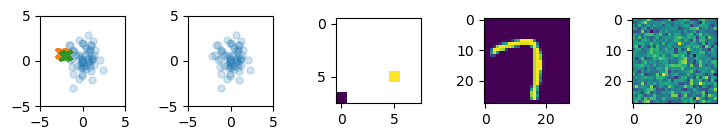

l 100 0.23915259540081024


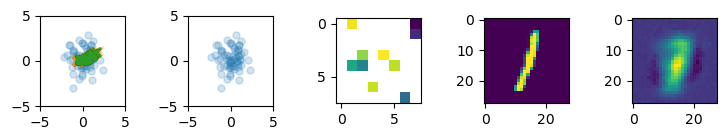

l 200 0.23542769253253937


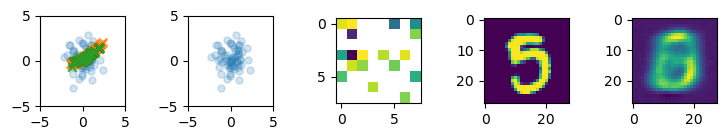

l 300 0.21810314059257507


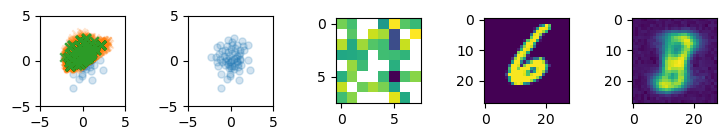

l 400 0.20509618520736694


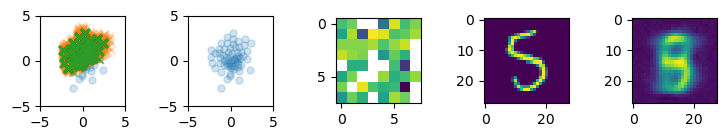

l 500 0.2122354656457901


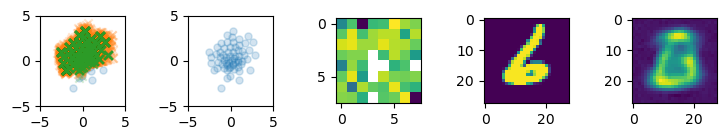

l 600 0.20904268324375153


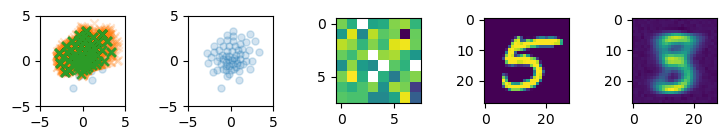

l 700 0.20133337378501892


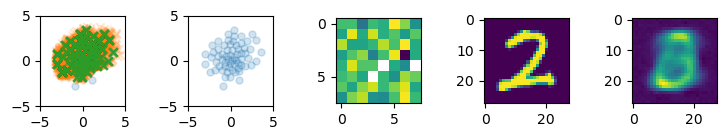

l 800 0.2078346610069275


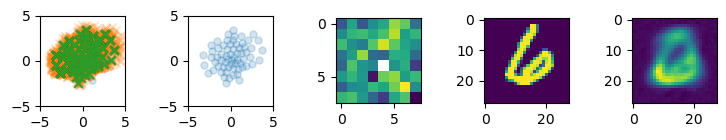

l 900 0.1973891258239746


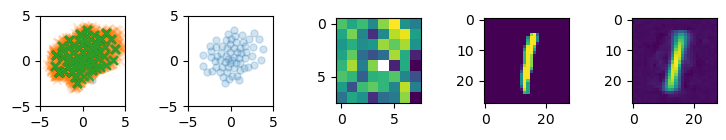

l 1000 0.20317944884300232


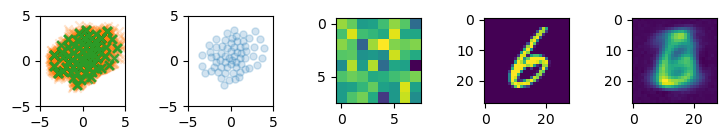

l 1100 0.20220981538295746


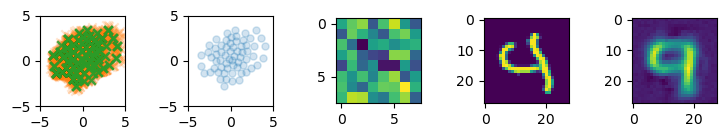

l 1200 0.2046680897474289


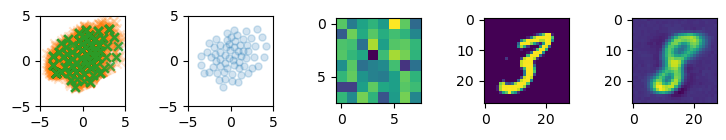

l 1300 0.20003825426101685


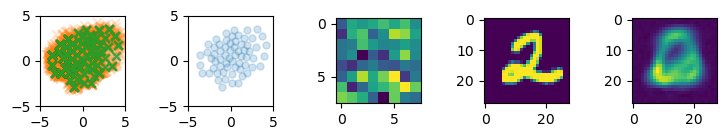

l 1400 0.20437926054000854


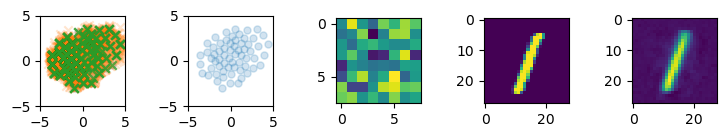

l 1500 0.20181283354759216


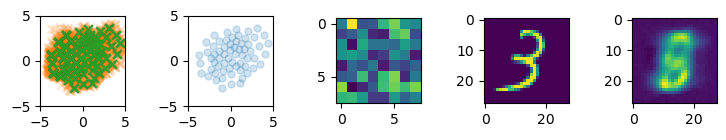

l 1600 0.20349256694316864


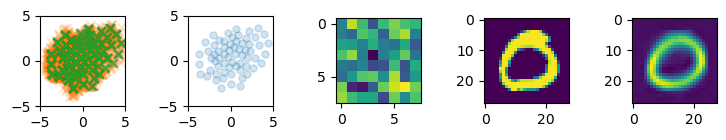

l 1700 0.20217402279376984


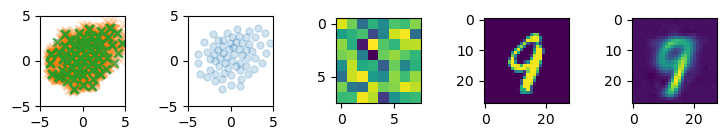

l 1800 0.20461294054985046


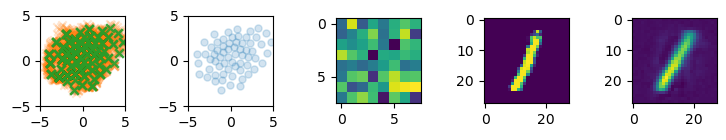

l 1900 0.20500154793262482


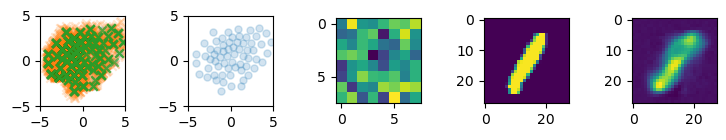

l 2000 0.1995910406112671


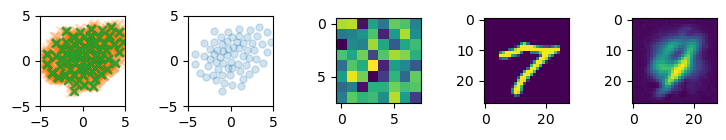

l 2100 0.20101481676101685


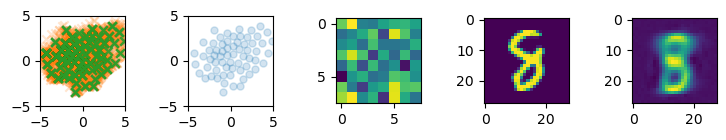

l 2200 0.20161086320877075


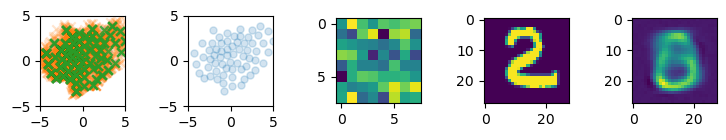

l 2300 0.2021961659193039


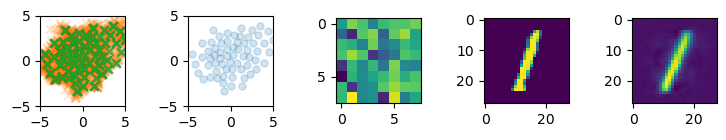

l 2400 0.1978260725736618


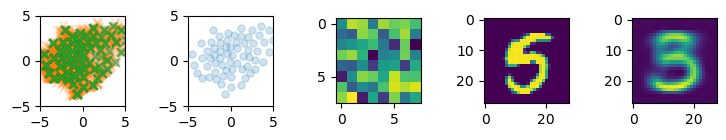

l 2500 0.20626389980316162


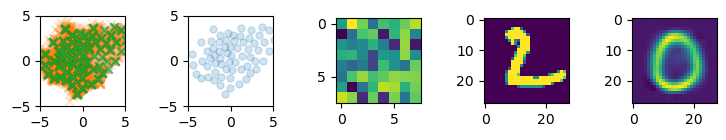

l 2600 0.20601288974285126


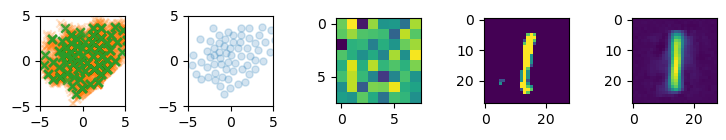

l 2700 0.21230964362621307


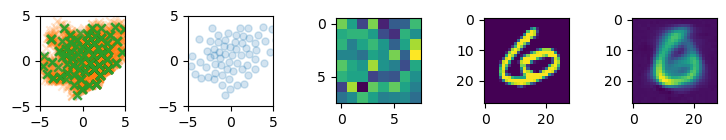

l 2800 0.20012764632701874


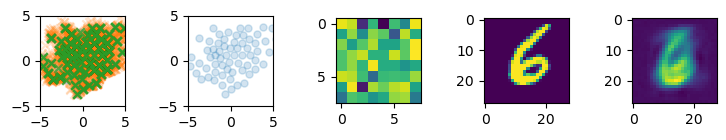

l 2900 0.19873565435409546


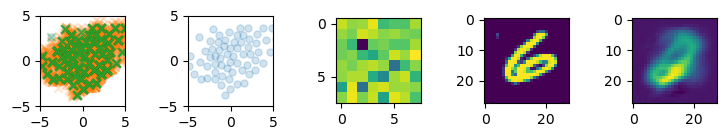

l 3000 0.19900338351726532


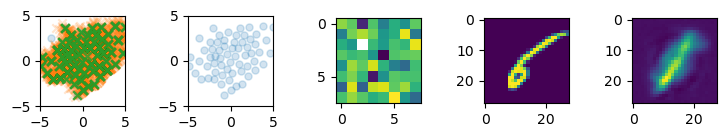

l 3100 0.20229117572307587


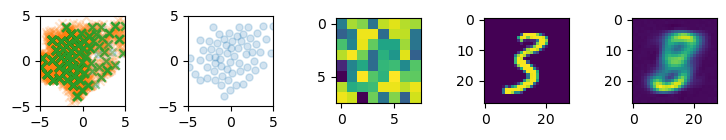

l 3200 0.2049694061279297


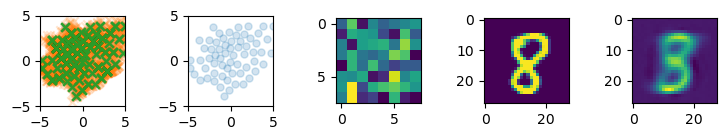

l 3300 0.1929621696472168


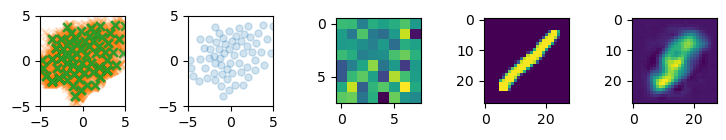

l 3400 0.19644182920455933


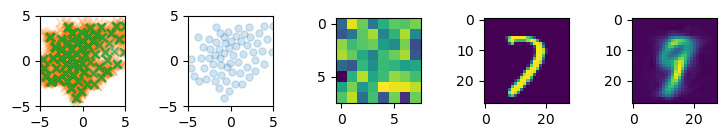

l 3500 0.19885039329528809


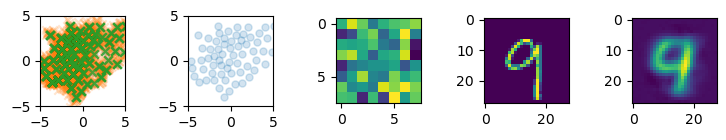

l 3600 0.20199891924858093


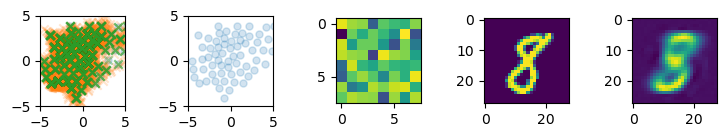

l 3700 0.19729267060756683


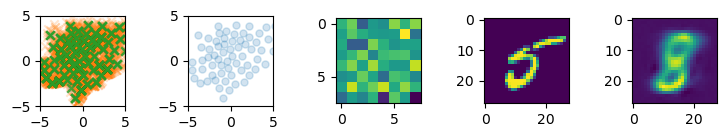

l 3800 0.20448718965053558


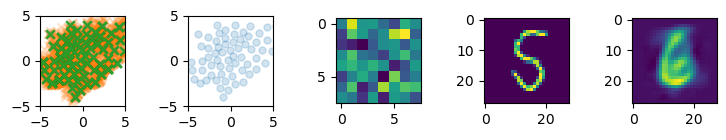

l 3900 0.1980048418045044


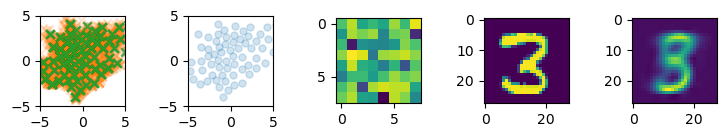

l 4000 0.20401740074157715


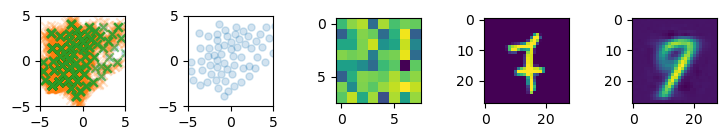

l 4100 0.20791204273700714


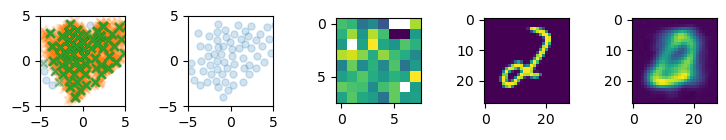

l 4200 0.2123633474111557


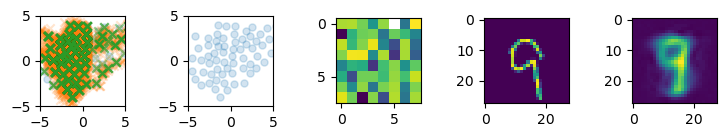

l 4300 0.2119676172733307


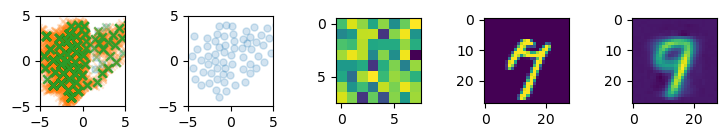

l 4400 0.1982620358467102


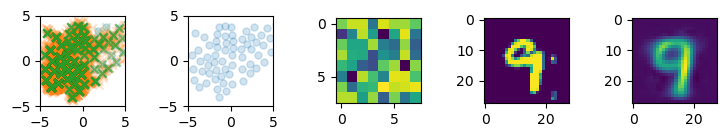

l 4500 0.21780714392662048


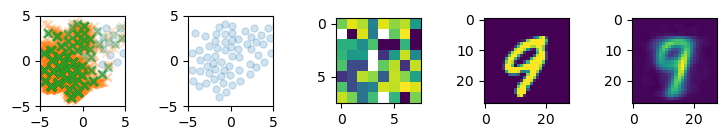

l 4600 0.19717279076576233


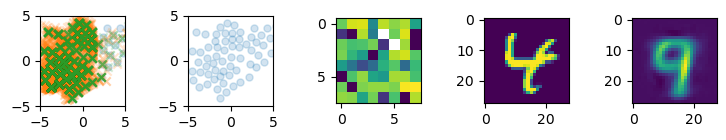

l 4700 0.2039858102798462


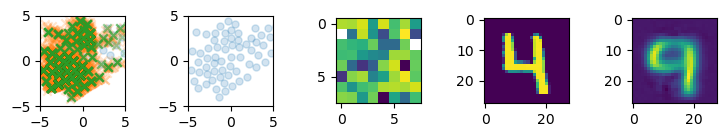

l 4800 0.19960090517997742


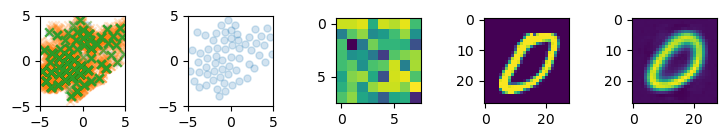

l 4900 0.20149491727352142


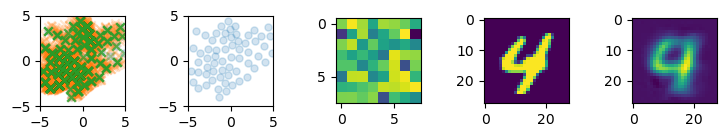

l 5000 0.20215928554534912


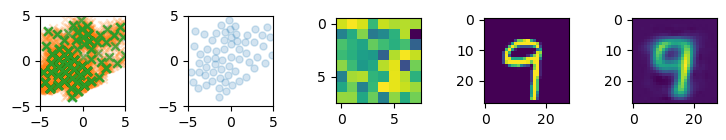

l 5100 0.2100669890642166


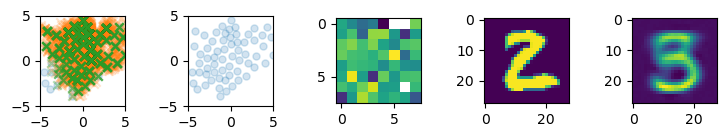

l 5200 0.20398449897766113


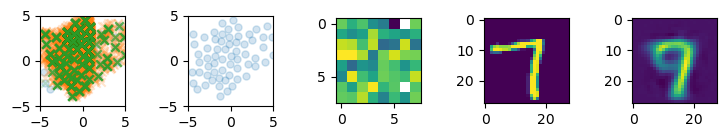

l 5300 0.20774202048778534


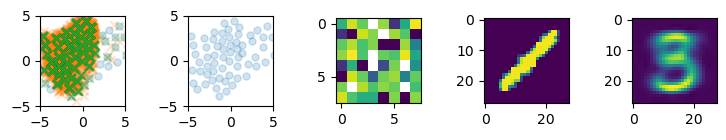

l 5400 0.2103995382785797


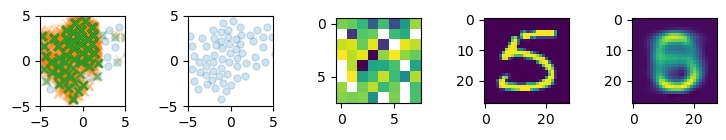

l 5500 0.2081758677959442


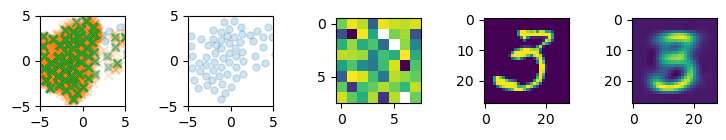

l 5600 0.2024308443069458


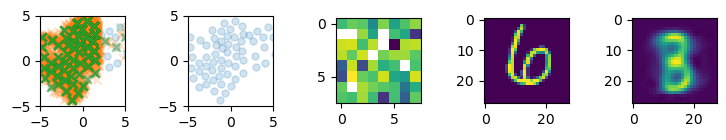

l 5700 0.19912658631801605


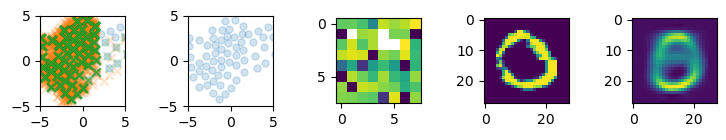

l 5800 0.2170645147562027


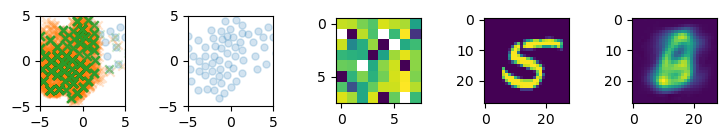

l 5900 0.2007153481245041


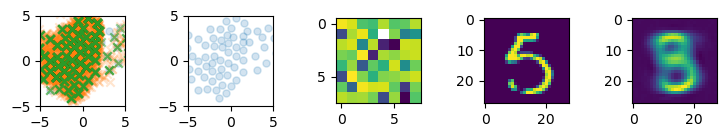

l 6000 0.20913811028003693


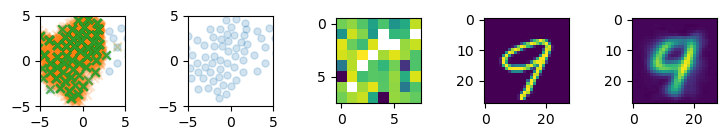

l 6100 0.21128441393375397


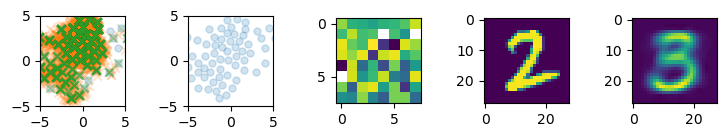

l 6200 0.2091439664363861


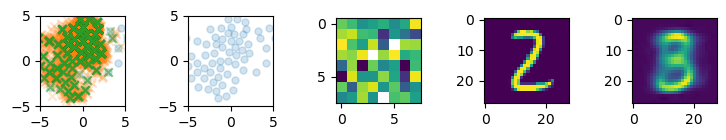

l 6300 0.21589769423007965


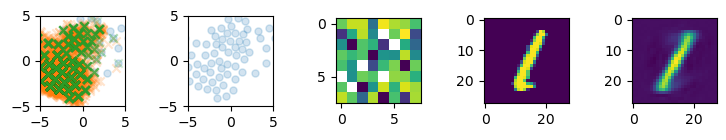

l 6400 0.20655663311481476


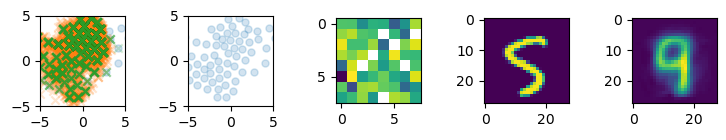

l 6500 0.20022349059581757


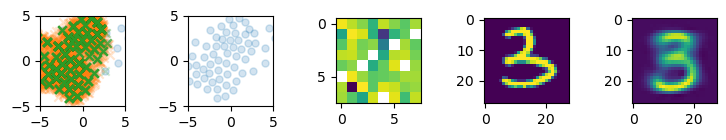

l 6600 0.21209277212619781


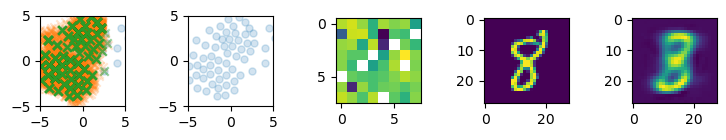

l 6700 0.21024303138256073


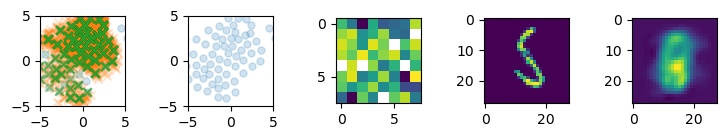

l 6800 0.20559579133987427


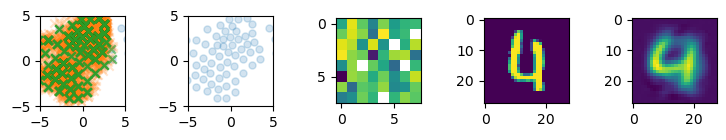

l 6900 0.20566348731517792


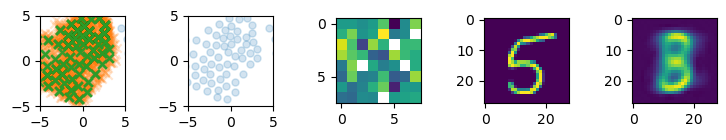

l 7000 0.2019883245229721


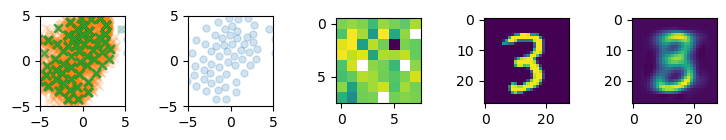

l 7100 0.20061317086219788


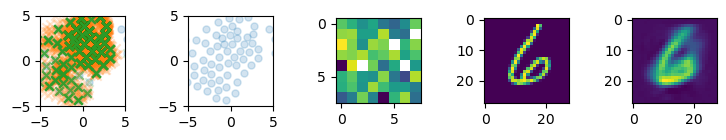

l 7200 0.2030230164527893


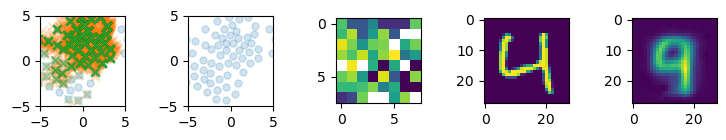

l 7300 0.2033703774213791


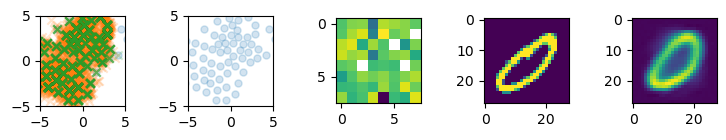

l 7400 0.20273306965827942


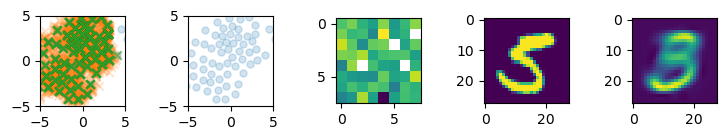

l 7500 0.20915941894054413


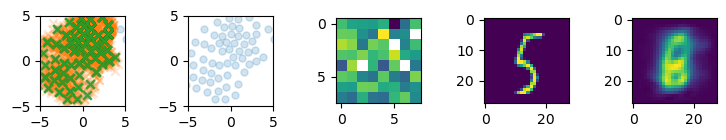

l 7600 0.2120312601327896


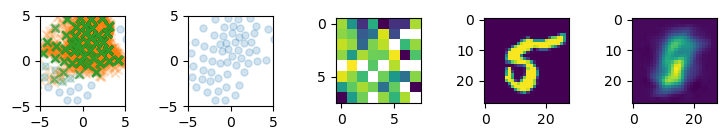

l 7700 0.20902645587921143


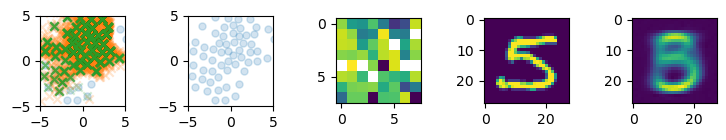

l 7800 0.20725134015083313


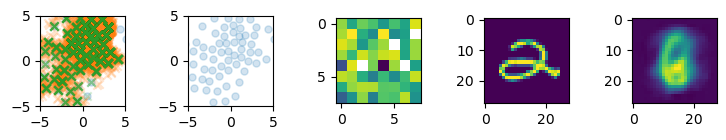

l 7900 0.20390933752059937


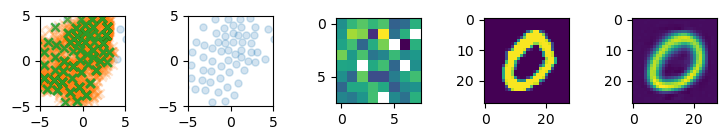

l 8000 0.2045881748199463


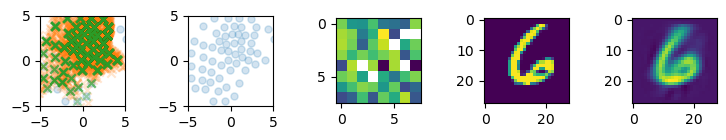

l 8100 0.20732605457305908


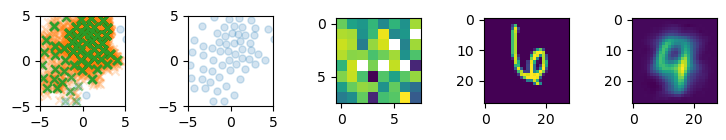

l 8200 0.20261183381080627


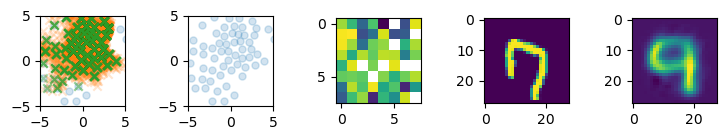

l 8300 0.2080622911453247


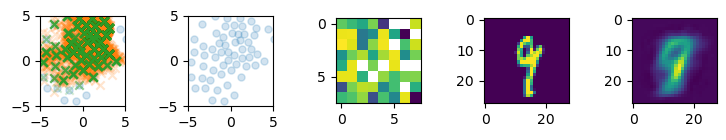

l 8400 0.2045695036649704


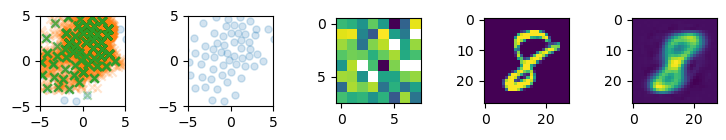

l 8500 0.2060309648513794


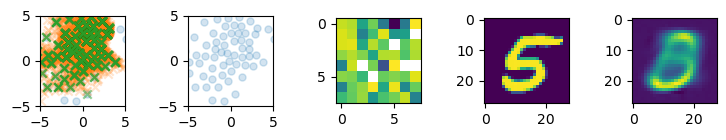

l 8600 0.20216427743434906


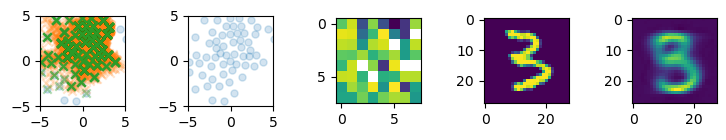

l 8700 0.19868846237659454


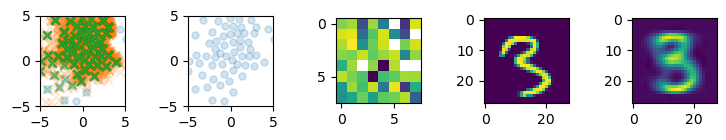

l 8800 0.20139996707439423


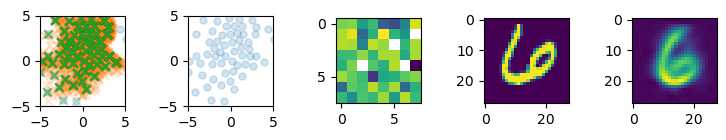

l 8900 0.20410063862800598


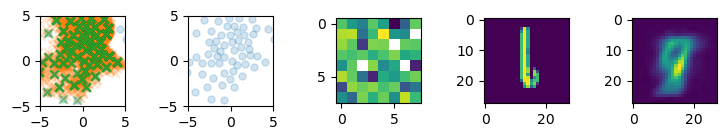

l 9000 0.20386415719985962


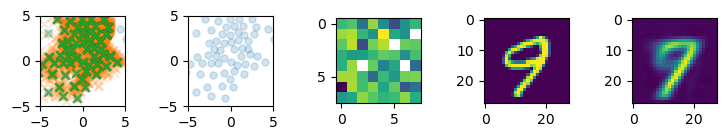

l 9100 0.20849579572677612


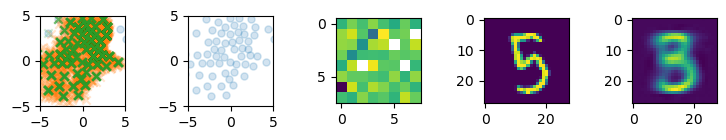

l 9200 0.20107199251651764


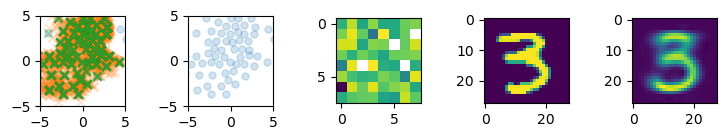

l 9300 0.1957845389842987


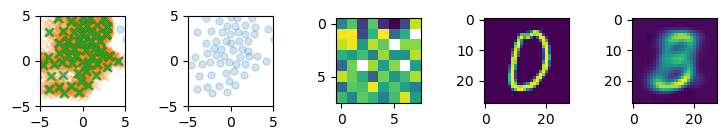

l 9400 0.20262111723423004


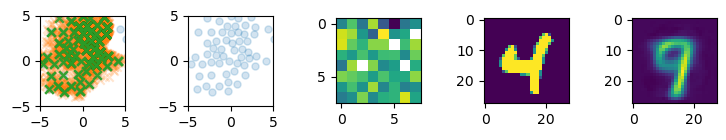

l 9500 0.20295965671539307


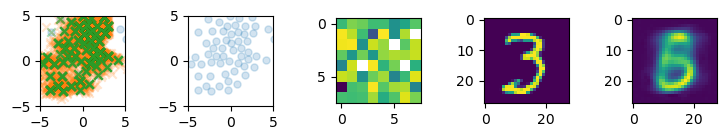

l 9600 0.1995420604944229


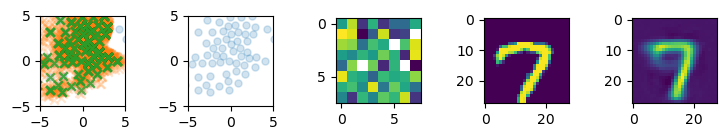

l 9700 0.19718889892101288


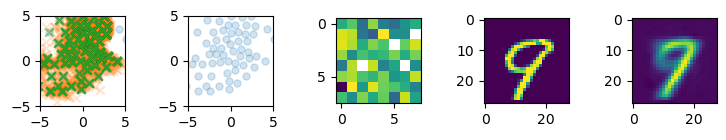

l 9800 0.20301271975040436


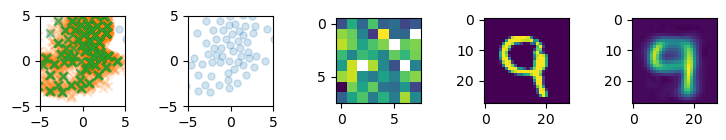

l 9900 0.20599031448364258


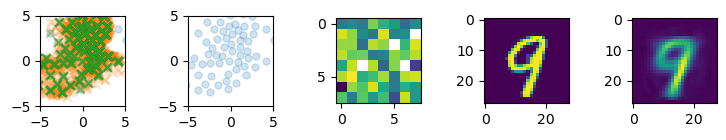

In [171]:
def loss_fn(model, x):
    r,z_e,z_q1,idx = model(x)
    z_e_stopped = z_e.clone().detach()
    z_q_stopped = z_q1.clone().detach()
    
    reco = torch.nn.functional.mse_loss(r,x) # get good reco
    learn_c = torch.nn.functional.mse_loss(z_e_stopped,z_q1) # move codes closer to "fixed" embeddings
    commit = torch.nn.functional.mse_loss(z_e,z_q_stopped)   # move embeddings closer to "fixed" codes

    loss = reco + 0.1*learn_c + 0.05*commit
    return loss

def plot_model(model,samples):
    with torch.no_grad():
        r,z_e,z_q1,idx = model(samples)
        z_q = z_q1
    bk = model.codebook.detach()
    f,axarr = plt.subplots(1,5)
    ax = axarr[0]
    ax.scatter(bk[:,0],bk[:,1], alpha = 0.2, s = 26)
    ax.scatter(z_e[:,0],z_e[:,1], alpha = 0.2, marker = 'x')
    ax.scatter(z_q[:,0],z_q[:,1], alpha = 0.2, marker = 'x')
    ax.set_xlim(-5,5)
    ax.set_ylim(-5,5)


    ax = axarr[1]
    ax.scatter(bk[:,0],bk[:,1], alpha = 0.2, s = 26)
    ax.set_xlim(-5,5)
    ax.set_ylim(-5,5)

    
    ax = axarr[2]
    counts,_ = np.histogram(idx, bins = np.arange(model.codebook_size**2 + 1))
    ax.imshow(np.log(counts).reshape(model.codebook_size,model.codebook_size))
    
    ax = axarr[3]
    ax.imshow(samples[0].reshape(28,28))

    ax = axarr[4]
    ax.imshow(r[0].reshape(28,28))
    f.set_tight_layout(True)
    f.set_size_inches(len(axarr)*1.5,1.5)

def train_vae():
    model = VQVAE()
    opt = optim.Adam(model.parameters(),5e-3)
    for i in range(10_000):
        model.zero_grad()
        samples,labels = sample_mnist(500, labels = True)
        loss = loss_fn(model,samples)
        loss.backward()
        opt.step()
        if i % 100 == 0:
            print('l',i,float(loss))
        if i % 100 == 0:
            samples,labels = sample_mnist(2000, labels = True)
            plot_model(model,samples)
            plt.show()
    return model


    
model = train_vae() 
# vae = VQVAE()
# x = torch.randn(1,784)
# loss = loss_fn(vae, x)
# loss.backward()

In [172]:
!open .